In [6]:
import numpy as np
import torch
from recovar_torch.config import BATCH_SIZE
from recovar_torch.representation_learning_models import (
    RepresentationLearningSingleAutoencoder,
    RepresentationLearningDenoisingSingleAutoencoder,
    RepresentationLearningMultipleAutoencoder,
)
from recovar_torch.classifier_models import (
    ClassifierAutocovariance,
    ClassifierAugmentedAutoencoder,
    ClassifierMultipleAutoencoder,
)
from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

In [7]:
TEST_DATA_PATH = "data/X_test_1280sample.npy"
TEST_LABEL_PATH = "data/Y_test_1280sample.npy"

MODEL_PATH = "checkpoints/representation_cross_covariances.pt"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [8]:
X_test = np.load(TEST_DATA_PATH).astype(np.float32)
print(f"Test data shape: {X_test.shape}")

Y_test = np.load(TEST_LABEL_PATH)
print(f"Test label shape: {Y_test.shape}")

Test data shape: (1280, 3000, 3)
Test label shape: (1280,)


In [9]:
# model = RepresentationLearningSingleAutoencoder()
# model = RepresentationLearningDenoisingSingleAutoencoder(
#     input_noise_std=1e-6, denoising_noise_std=2e-1)
model = RepresentationLearningMultipleAutoencoder(input_noise_std=1e-6, eps=1e-27).to(DEVICE)

In [10]:
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

RepresentationLearningMultipleAutoencoder(
  (normalize1): NormalizeStd()
  (add_noise): AddNoise()
  (normalize2): NormalizeStd()
  (autoencoders): ModuleList(
    (0-4): 5 x AutoencoderBlock(
      (down1): Downsample(
        (padding): Padding()
        (conv): Conv1d(3, 8, kernel_size=(15,), stride=(2,))
        (bn): BatchNorm1d(8, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      )
      (down2): Downsample(
        (padding): Padding()
        (conv): Conv1d(8, 16, kernel_size=(13,), stride=(2,))
        (bn): BatchNorm1d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      )
      (pad1): Padding()
      (down3): Downsample(
        (padding): Padding()
        (conv): Conv1d(16, 32, kernel_size=(11,), stride=(2,))
        (bn): BatchNorm1d(32, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      )
      (down4): Downsample(
        (padding): Padding()
        (conv): Conv1d(32, 64, kernel_size=(9,), stride=(2,))
  

In [11]:
# model_classifier = ClassifierAutocovariance(model)
# model_classifier = ClassifierAugmentedAutoencoder(model)
model_classifier = ClassifierMultipleAutoencoder(model).to(DEVICE)
model_classifier.eval()

# RepresentationLearningMultipleAutoencoder is only compatible with ClassifierMultipleAutoencoder.
# RepresentationLearningSingleAutoencoder / RepresentationLearningDenoisingSingleAutoencoder are
# compatible with ClassifierAutocovariance and ClassifierAugmentedAutoencoder.

ClassifierMultipleAutoencoder(
  (model): RepresentationLearningMultipleAutoencoder(
    (normalize1): NormalizeStd()
    (add_noise): AddNoise()
    (normalize2): NormalizeStd()
    (autoencoders): ModuleList(
      (0-4): 5 x AutoencoderBlock(
        (down1): Downsample(
          (padding): Padding()
          (conv): Conv1d(3, 8, kernel_size=(15,), stride=(2,))
          (bn): BatchNorm1d(8, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        )
        (down2): Downsample(
          (padding): Padding()
          (conv): Conv1d(8, 16, kernel_size=(13,), stride=(2,))
          (bn): BatchNorm1d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        )
        (pad1): Padding()
        (down3): Downsample(
          (padding): Padding()
          (conv): Conv1d(16, 32, kernel_size=(11,), stride=(2,))
          (bn): BatchNorm1d(32, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        )
        (down4): Downsample(
       

In [12]:
scores = []
with torch.no_grad():
    for i in range(0, len(X_test), BATCH_SIZE):
        xb = torch.from_numpy(X_test[i : i + BATCH_SIZE]).to(DEVICE)
        scores.append(model_classifier(xb).cpu().numpy())
earthquake_scores = np.concatenate(scores)

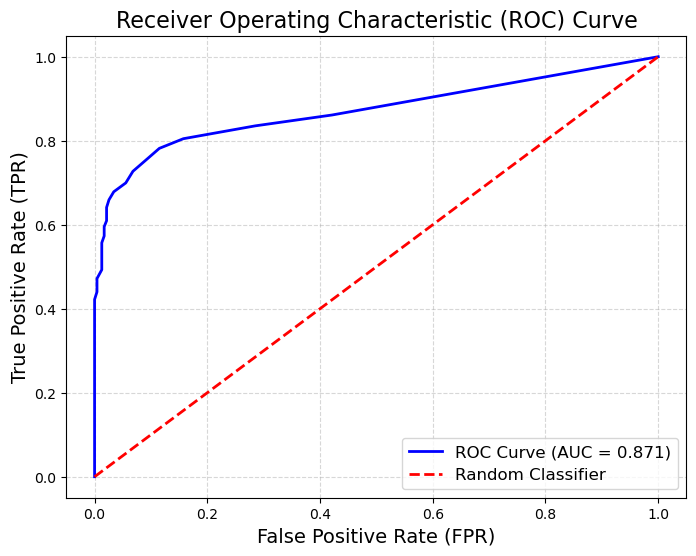

In [13]:
fpr, tpr, __ = roc_curve(Y_test, earthquake_scores)
auc_score = roc_auc_score(y_true=Y_test, y_score=earthquake_scores)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC Curve (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], color="red", lw=2, linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate (FPR)", fontsize=14)
plt.ylabel("True Positive Rate (TPR)", fontsize=14)
plt.title("Receiver Operating Characteristic (ROC) Curve", fontsize=16)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()